In [ ]:
import os
import sys

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    # Mount Drive
    drive.mount('/content/drive')

    # Clone Repository
    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "main"

    if not os.path.exists('/content/code'):
        print(f"Cloning repository from {REPO_URL}...")
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        print("Repository already exists.")
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    print(f"Current working directory: {os.getcwd()}")

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    # Install requirements
    print("Installing requirements...")
    !pip install -q torcheval loguru

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning repository from https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git...
Cloning into '/content/code'...
remote: Enumerating objects: 952, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 952 (delta 118), reused 112 (delta 96), pack-reused 786 (from 2)
Receiving objects: 100% (952/952), 97.86 MiB | 30.82 MiB/s, done.
Resolving deltas: 100% (508/508), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 13.22 MiB/s, done.
Resolving deltas: 100% (75/75), done.
S

## Data Preparation

Extract **both** Omnivore and SlowFast features from `1s.zip`.

In [ ]:
import shutil
import glob

if IN_COLAB:
    print("Setting up data...")

    drive_base_path = "/content/drive/MyDrive/AML_Project"
    data_zip = f"{drive_base_path}/1s.zip"

    # Fallback search
    if not os.path.exists(data_zip):
        print(f"1s.zip not found at {data_zip}, searching...")
        for p in ["/content/drive/MyDrive/MistakeDetection/1s.zip", "/content/drive/MyDrive/1s.zip"]:
            if os.path.exists(p):
                data_zip = p
                break

    if os.path.exists(data_zip):
        print(f"Found data zip at: {data_zip}")

        # Extract main zip
        !mkdir -p data
        !unzip -q -n "{data_zip}" -d data

        # Extract BOTH backbones
        backbones = ["omnivore", "slowfast"]

        for backbone in backbones:
            nested_zip = f"data/1s/video/{backbone}.zip"
            target_dir = f"data/video/{backbone}"

            if os.path.exists(nested_zip):
                print(f"\nExtracting {backbone}...")
                !mkdir -p {target_dir}
                temp_extract = f"data/temp_{backbone}"
                !unzip -q -n "{nested_zip}" -d {temp_extract}

                # Move files
                files = glob.glob(f"{temp_extract}/**/*.npz", recursive=True)
                for f in files:
                    shutil.move(f, target_dir)

                print(f"Moved {len(files)} files for {backbone}")
                !rm -rf {temp_extract}
            else:
                print(f"WARNING: {nested_zip} not found")

        # Cleanup
        if os.path.exists("data/1s"):
            !rm -rf data/1s

        print("\nData setup complete!")
        print(f"Omnivore files: {len(os.listdir('data/video/omnivore')) if os.path.exists('data/video/omnivore') else 0}")
        print(f"SlowFast files: {len(os.listdir('data/video/slowfast')) if os.path.exists('data/video/slowfast') else 0}")
    else:
        print("CRITICAL: '1s.zip' not found in Drive!")

Setting up data...
Found data zip at: /content/drive/MyDrive/AML_Project/1s.zip

Extracting omnivore...
Moved 384 files for omnivore

Extracting slowfast...
Moved 384 files for slowfast

Data setup complete!
Omnivore files: 384
SlowFast files: 384


## Training Configuration

We define the 4 configurations to train systematically.

In [1]:
# Training configurations
#
# TRAINING STRATEGY:
# - Omnivore configs use 15 epochs, SlowFast configs use 30 (the best model is
#   automatically saved based on validation AUC either way)
# - Even with overfitting, we see all epochs and the best model state is preserved
# - Results logged per epoch show the progression (best F1 may be at epoch 12-14 for Omnivore)
#
# EVALUATION THRESHOLDS (matching paper methodology):
# - step split: threshold = 0.6
# - recordings split: threshold = 0.5
#
# pos_weight=2.5 is used (default from CaptainCook4D repo)

CONFIGS = [
    {"backbone": "omnivore", "split": "step",       "epochs": 15, "batch_size": 32},
    {"backbone": "omnivore", "split": "recordings", "epochs": 15, "batch_size": 32},
    {"backbone": "slowfast", "split": "step",       "epochs": 30, "batch_size": 32},
    {"backbone": "slowfast", "split": "recordings", "epochs": 30, "batch_size": 32},
]

print("Training Configurations:")
print("-" * 60)
for i, cfg in enumerate(CONFIGS, 1):
    threshold = 0.5 if cfg['split'] == 'recordings' else 0.6
    print(f"  {i}. {cfg['backbone']:10} | {cfg['split']:12} | {cfg['epochs']:2} epochs | threshold={threshold}")
print("-" * 60)
print("Note: Best model saved automatically based on validation AUC")

Training Configurations:
------------------------------------------------------------
  1. omnivore   | step         | 15 epochs | threshold=0.6
  2. omnivore   | recordings   | 15 epochs | threshold=0.5
  3. slowfast   | step         | 30 epochs | threshold=0.6
  4. slowfast   | recordings   | 30 epochs | threshold=0.5
------------------------------------------------------------
Note: Best model saved automatically based on validation AUC


## Configuration 1: Omnivore + Step Split

In [ ]:
# Configuration 1: Omnivore + Step
# Best model is automatically saved based on AUC
# Evaluation threshold: 0.6 (step split default)
!python train_er.py \
    --backbone omnivore \
    --variant LSTM \
    --num_epochs 15 \
    --split step \
    --batch_size 32 \
    --modality video \
    --threshold 0.6

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_192925-vporw5em
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run snowy-sound-1
wandb: ⭐️ View project at https:/

## Configuration 2: Omnivore + Recordings Split

In [ ]:
# Configuration 2: Omnivore + Recordings
# Best model is automatically saved based on AUC
# Evaluation threshold: 0.5 (recordings split uses lower threshold per paper)
!python train_er.py \
    --backbone omnivore \
    --variant LSTM \
    --num_epochs 15 \
    --split recordings \
    --batch_size 32 \
    --modality video \
    --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_194030-jpznswap
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run unique-snowflake-4
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_lstm_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_lstm_video/runs/jpznswap
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 

## Configuration 3: SlowFast + Step Split

In [ ]:
# Configuration 3: SlowFast + Step
# Stable training with no significant overfitting
# Best model is automatically saved based on AUC
# Evaluation threshold: 0.6 (step split default)
!python train_er.py \
    --backbone slowfast \
    --variant LSTM \
    --num_epochs 30 \
    --split step \
    --batch_size 32 \
    --modality video \
    --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_195119-07ogggxl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run lunar-spaceship-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_slowfast_LSTM_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_slowfast_LSTM_video/runs/07ogggxl
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
{'batch_size': 32, 'test_batch_size': 1, 'num_e

## Configuration 4: SlowFast + Recordings Split

In [ ]:
# Configuration 4: SlowFast + Recordings
# Stable training with no significant overfitting
# Best model is automatically saved based on AUC
# Evaluation threshold: 0.5 (recordings split uses lower threshold per paper)
!python train_er.py \
    --backbone slowfast \
    --variant LSTM \
    --num_epochs 30 \
    --split recordings \
    --batch_size 32 \
    --modality video \
    --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260106_200758-6mcm1vp6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run kind-vortex-1
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_slowfast_LSTM_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_slowfast_LSTM_video/runs/6mcm1vp6
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
{'batch_size': 32, 'test_batch_size': 1

---

## V1 (MLP) and V2 (Transformer) Baseline Reproduction

The following experiments reproduce the V1 (MLP) and V2 (Transformer) baselines from CaptainCook4D paper using **our training setup** for fair comparison with V3 (LSTM).

**Note:** `colab_quickstart.ipynb` contains checkpoint-based evaluation using pre-trained weights from the CaptainCook4D repository. The cells below train from scratch using our training infrastructure.

**Required for Table 1 (Baseline Reproduction) in the technical report.**

### Paper Results (from CaptainCook4D):
| Model | Backbone | Split | Paper F1 |
|-------|----------|-------|----------|
| V1 (MLP) | Omnivore | step | 24.26% |
| V2 (Transformer) | Omnivore | step | 55.39% |
| V1 (MLP) | Omnivore | recordings | 50.91% |
| V2 (Transformer) | Omnivore | recordings | 39.04% |

### V1 (MLP) - Omnivore + Step Split

In [ ]:
# V1 (MLP) Baseline Reproduction - Omnivore + Step
# Paper reports F1 = 24.26% for this configuration; our measured result is in the
# Results Summary section below (55.50% - see the reproduction-mismatch discussion there)
!python train_er.py \
    --backbone omnivore \
    --variant MLP \
    --num_epochs 15 \
    --split step \
    --batch_size 32 \
    --modality video \
    --threshold 0.6

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run o44nysf9 (0.1s)
wandb: ⣽ setting up run o44nysf9 (0.1s)
wandb: ⣾ setting up run o44nysf9 (0.1s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_172909-o44nysf9
wandb: Run `wandb offline` to t

### V2 (Transformer) - Omnivore + Step Split

In [ ]:
# V2 (Transformer) Baseline Reproduction - Omnivore + Step
# Paper reports F1 = 55.39% for this configuration; our measured result is in the
# Results Summary section below (44.19% - see the reproduction-mismatch discussion there)
!python train_er.py \
    --backbone omnivore \
    --variant Transformer \
    --num_epochs 15 \
    --split step \
    --batch_size 32 \
    --modality video \
    --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run jp8vdci8 (0.2s)
wandb: ⣽ setting up run jp8vdci8 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_173651-jp8vdci8
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run legendary-universe-13
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/jp8vdci8
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'ba

### V1 (MLP) - Omnivore + Recordings Split

In [ ]:
# V1 (MLP) Baseline Reproduction - Omnivore + Recordings
# Paper reports F1 = 50.91% for this configuration; our measured result is in the
# Results Summary section below (55.77% - see the reproduction-mismatch discussion there)
!python train_er.py \
    --backbone omnivore \
    --variant MLP \
    --num_epochs 15 \
    --split recordings \
    --batch_size 32 \
    --modality video \
    --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run whty44a5 (0.2s)
wandb: ⣽ setting up run whty44a5 (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_174504-whty44a5
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run usual-valley-12
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/whty44a5
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size':

### V2 (Transformer) - Omnivore + Recordings Split

In [ ]:
# V2 (Transformer) Baseline Reproduction - Omnivore + Recordings
# Paper reports F1 = 39.04% for this configuration; our measured result is in the
# Results Summary section below (54.00% - see the reproduction-mismatch discussion there)
!python train_er.py \
    --backbone omnivore \
    --variant Transformer \
    --num_epochs 15 \
    --split recordings \
    --batch_size 32 \
    --modality video \
    --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ setting up run 09e6plpl (0.2s)
wandb: ⣽ setting up run 09e6plpl (0.2s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_175230-09e6plpl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run magic-energy-13
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/09e6plpl
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': Fals

---

## Results Summary

Every number in this section is the final `test Step Level Metrics` line printed by the
corresponding run above - no approximations. `train_er.py` evaluates on the test set after
every epoch, so the last line is the **final epoch**, not a model selected on validation.
The final-epoch figure is what we report, and the spread column says how much trust it
deserves.

**Training details**

- `pos_weight = 2.5` (the CaptainCook4D repository default)
- 15 epochs for Omnivore configs, 30 for SlowFast configs (both the LSTM baseline and the
  V1/V2 reproductions above)
- Evaluation thresholds: **step = 0.6, recordings = 0.5**, selected automatically from the split
- Task: overall error recognition (`has_errors`), positive rate 34.5% across the 5700 steps

### LSTM (our added baseline)

| Backbone | Split | Epochs | Final F1 (%) | Best F1 (%) | F1 over last 5 epochs | Final AUC | Accuracy (%) |
|----------|-------|--------|--------------|-------------|------------------------|-----------|--------------|
| Omnivore | step | 15 | 49.64 | 59.64 | 49.64–59.64 (10.00) | 0.769 | 73.81 |
| Omnivore | recordings | 15 | 47.50 | 54.86 | 47.01–54.37 (7.35) | 0.610 | 60.80 |
| SlowFast | step | 30 | 51.05 | 51.87 | 50.53–51.05 (0.53) | 0.683 | 47.62 |
| SlowFast | recordings | 30 | 55.53 | 55.53 | 53.63–55.53 (1.89) | 0.590 | 48.44 |

**The Omnivore runs are not converged and their F1 is not a stable quantity.** Omnivore/step
moves 10 F1 points between its last two epochs (59.64 then 49.64) while its AUC barely moves
(0.775 then 0.769) - the decision boundary is drifting across a fixed 0.6 threshold, not the
ranking. Quoting any single-epoch Omnivore F1 to two decimals overstates what was measured.
The SlowFast runs, at 30 epochs, are stable to within 0.5–1.9 points.

### Our reproductions of the provided V1/V2 baselines (Omnivore)

| Model | Split | F1 (%) | AUC | Precision (%) | Recall (%) |
|-------|-------|--------|------|---------------|------------|
| V1 (MLP) | step | 55.50 | 0.816 | 68.64 | 46.59 |
| V2 (Transformer) | step | 44.19 | 0.708 | 51.05 | 38.96 |
| V1 (MLP) | recordings | 55.77 | 0.640 | 47.65 | 67.22 |
| V2 (Transformer) | recordings | 54.00 | 0.595 | 38.12 | 92.53 |

### CaptainCook4D paper baselines (Table 2), for reference

| Model | Backbone | Split | F1 (%) | AUC (%) |
|-------|----------|-------|--------|---------|
| MLP (V1) | Omnivore | step | 24.26 | 75.7 |
| Transformer (V2) | Omnivore | step | 55.39 | 75.7 |
| MLP (V1) | Omnivore | recordings | 50.91 | 63.03 |
| Transformer (V2) | Omnivore | recordings | 39.04 | 62.27 |

**Our reproduction does not match the published table on the step split, and the mismatch is
not small: we measure MLP 55.50 / Transformer 44.19 where the paper reports MLP 24.26 /
Transformer 55.39 - roughly the two models exchanged.** The AUCs are closer (0.816 and 0.708
against 0.757 for both). Recall explains part of it: our MLP reaches 46.59% recall at 68.64%
precision, an operating point that a different decision threshold would move a long way in
F1 while barely moving AUC. We report our own measured numbers throughout and treat the
published F1 column as not reproduced rather than as reproduced.


## Error Type Analysis (Optional)

Performance broken down by error type.

In [ ]:
# Error Type Analysis
# Break the annotated steps down by error tag.
#
# The tags are NOT in step_annotations.json. That file carries only a boolean
# `has_errors` per step, so reading step['error_category'] from it returns the
# fallback for every step and the breakdown degenerates to a single 'unknown'
# bucket holding 100% of the errors. The tags live in error_annotations.json,
# where each step carries an `errors` list and each entry has a `tag`.
#
# Note that tags outnumber error steps: a step can carry more than one tag, so
# the percentages below are shares of tags, not shares of steps.

import json
import os
from collections import Counter

STEP_ANNOTATIONS = "annotations/annotation_json/step_annotations.json"
ERROR_ANNOTATIONS = "annotations/annotation_json/error_annotations.json"

if os.path.exists(STEP_ANNOTATIONS) and os.path.exists(ERROR_ANNOTATIONS):
    with open(STEP_ANNOTATIONS, "r") as f:
        step_annotations = json.load(f)
    with open(ERROR_ANNOTATIONS, "r") as f:
        error_annotations = json.load(f)

    total_steps = sum(len(rec["steps"]) for rec in step_annotations.values())
    error_steps = sum(1 for rec in step_annotations.values()
                      for step in rec["steps"] if step.get("has_errors"))

    tag_counts = Counter()
    tagged_steps = 0
    for recording in error_annotations:
        for step in recording.get("step_annotations", []):
            errors = step.get("errors") or []
            if errors:
                tagged_steps += 1
            for err in errors:
                tag_counts[err.get("tag", "untagged")] += 1

    total_tags = sum(tag_counts.values())

    print(f"Recordings        : {len(step_annotations)}")
    print(f"Annotated steps   : {total_steps}")
    print(f"Steps with errors : {error_steps} ({100 * error_steps / total_steps:.1f}%)")
    print(f"Error tags        : {total_tags} across {tagged_steps} steps "
          f"({total_tags / tagged_steps:.2f} tags per error step)")

    print("\nError tag distribution:")
    for tag, count in tag_counts.most_common():
        print(f"  {tag:<20} {count:>5} ({100 * count / total_tags:>5.1f}% of tags,"
              f" {100 * count / total_steps:>4.1f}% of steps)")

    print("""
Two facts here shape every result in this project:

  Order Error is the largest single tag, and an ordering mistake changes neither
  the set of steps performed nor their appearance - only their sequence. A model
  pooling over per-step features has no way to see it.

  Missing Step means a step was never performed. Any representation that encodes
  how many canonical steps were realized can detect that class without looking at
  the video at all. Substep 4 measures exactly how far that shortcut goes.""")
else:
    missing = [p for p in (STEP_ANNOTATIONS, ERROR_ANNOTATIONS) if not os.path.exists(p)]
    print("Annotations not found: " + ", ".join(missing))
    print("Run the data preparation cell first.")


Recordings        : 384
Annotated steps   : 5700
Steps with errors : 1964 (34.5%)
Error tags        : 2574 across 1964 steps (1.31 tags per error step)

Error tag distribution:
  Order Error            795 ( 30.9% of tags, 13.9% of steps)
  Technique Error        502 ( 19.5% of tags,  8.8% of steps)
  Preparation Error      410 ( 15.9% of tags,  7.2% of steps)
  Measurement Error      331 ( 12.9% of tags,  5.8% of steps)
  Missing Step           285 ( 11.1% of tags,  5.0% of steps)
  Timing Error           177 (  6.9% of tags,  3.1% of steps)
  Temperature Error       66 (  2.6% of tags,  1.2% of steps)
  Other                    8 (  0.3% of tags,  0.1% of steps)

Two facts here shape every result in this project:

  Order Error is the largest single tag, and an ordering mistake changes neither
  the set of steps performed nor their appearance - only their sequence. A model
  pooling over per-step features has no way to see it.

  Missing Step means a step was never performed. Any rep

---
## LSTM Overfitting Analysis

This experiment demonstrates the "Capacity Trap" - where larger LSTMs with more capacity can perfectly memorize training data but fail to generalize to test data.

In [ ]:
# ==============================================================================
# LSTM OVERFITTING ANALYSIS - "CAPACITY TRAP" DEMONSTRATION
# ==============================================================================
# Tests different LSTM hidden sizes to show overfitting behavior

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import argparse

# Define different LSTM capacities to test
HIDDEN_SIZES = [64, 128, 256, 512, 1024]
NUM_EPOCHS = 30

overfitting_results = {}

print("=" * 70)
print("LSTM OVERFITTING ANALYSIS - CAPACITY TRAP")
print("Testing hidden sizes:", HIDDEN_SIZES)
print("=" * 70)

# Define a Local Custom LSTM to allow variable hidden sizes
# (The original class hardcodes hidden_dim=512)
class CustomLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout=0.0):
        super(CustomLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Robustness: Handle NaNs
        x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)

        # Handle unbatched input
        is_unbatched = x.dim() == 2
        if is_unbatched:
            x = x.unsqueeze(0)

        out, _ = self.lstm(x)
        logits = self.fc(out)

        if is_unbatched:
            logits = logits.squeeze(0)

        return logits

# Load data
try:
    from dataloader.CaptainCookStepDataset import CaptainCookStepDataset, collate_fn

    # Create a mock config object with ALL required fields
    config = argparse.Namespace(
        backbone='omnivore',
        modality=['video'],
        segment_features_directory='data',  # Added: Path to feature files
        task_name='error_recognition',      # Added: Task type
        seed=42                             # Added: Random seed
    )

    # Create datasets
    print("Loading datasets...")
    train_dataset = CaptainCookStepDataset(config, phase='train', split='recordings')
    test_dataset = CaptainCookStepDataset(config, phase='test', split='recordings')

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_fn)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_dim = 1024  # Omnivore feature dimension

    for hidden_size in HIDDEN_SIZES:
        print(f"\n>>> Hidden Size: {hidden_size} <<<")

        # Use CustomLSTM instead of the fixed repo model
        model = CustomLSTM(input_dim=input_dim, hidden_dim=hidden_size, num_layers=2, dropout=0.0).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        # pos_weight=2.5 to handle class imbalance
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.5]).to(device))

        train_accs = []
        test_accs = []

        for epoch in range(NUM_EPOCHS):
            # Training
            model.train()
            train_correct, train_total = 0, 0
            for batch in train_loader:
                features, labels = batch[0].to(device), batch[1].to(device)

                optimizer.zero_grad()
                outputs = model(features)
                loss = criterion(outputs.squeeze(), labels.float().squeeze())
                loss.backward()
                optimizer.step()

                preds = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
                train_correct += (preds == labels.squeeze()).sum().item()
                train_total += labels.size(0)

            train_acc = train_correct / train_total
            train_accs.append(train_acc)

            # Testing
            model.eval()
            test_correct, test_total = 0, 0
            with torch.no_grad():
                for batch in test_loader:
                    features, labels = batch[0].to(device), batch[1].to(device)
                    outputs = model(features)
                    preds = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
                    test_correct += (preds == labels.squeeze()).sum().item()
                    test_total += labels.size(0)

            test_acc = test_correct / test_total
            test_accs.append(test_acc)

            if (epoch + 1) % 10 == 0:
                gap = train_acc - test_acc
                print(f"  Epoch {epoch+1}: Train Acc={train_acc*100:.1f}%, Test Acc={test_acc*100:.1f}%, GAP={gap*100:.1f}%")

        # Store results
        overfitting_results[hidden_size] = {
            'final_train_acc': train_accs[-1],
            'final_test_acc': test_accs[-1],
            'max_train_acc': max(train_accs),
            'max_test_acc': max(test_accs),
            'overfitting_gap': train_accs[-1] - test_accs[-1],
            'train_history': train_accs,
            'test_history': test_accs
        }

    print("\n" + "=" * 70)
    print("OVERFITTING SUMMARY - THE CAPACITY TRAP")
    print("=" * 70)
    print(f"{'Hidden Size':<12} | {'Train Acc':<10} | {'Test Acc':<10} | {'Gap':<10}")
    print("-" * 50)
    for hs in HIDDEN_SIZES:
        r = overfitting_results[hs]
        print(f"{hs:<12} | {r['final_train_acc']*100:>8.1f}% | {r['final_test_acc']*100:>8.1f}% | {r['overfitting_gap']*100:>+8.1f}%")

    print("\n>>> KEY OBSERVATION <<<")
    print("Larger LSTMs show HIGHER training accuracy but SIMILAR or WORSE test accuracy")
    print("This demonstrates the 'Capacity Trap' in data-limited regimes")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"Error: {e}")
    print("Make sure to run the data loading cells first")

LSTM OVERFITTING ANALYSIS - CAPACITY TRAP
Testing hidden sizes: [64, 128, 256, 512, 1024]
Loading datasets...
Loaded annotations...... 
Loading recording ids from recordings_combined_splits.json
Loaded annotations...... 
Loading recording ids from recordings_combined_splits.json

>>> Hidden Size: 64 <<<
  Epoch 10: Train Acc=90.7%, Test Acc=60.8%, GAP=29.9%
  Epoch 20: Train Acc=95.5%, Test Acc=64.1%, GAP=31.4%
  Epoch 30: Train Acc=95.9%, Test Acc=61.1%, GAP=34.8%

>>> Hidden Size: 128 <<<
  Epoch 10: Train Acc=91.0%, Test Acc=62.1%, GAP=29.0%
  Epoch 20: Train Acc=96.1%, Test Acc=61.6%, GAP=34.5%
  Epoch 30: Train Acc=98.3%, Test Acc=62.2%, GAP=36.1%

>>> Hidden Size: 256 <<<
  Epoch 10: Train Acc=91.3%, Test Acc=63.3%, GAP=28.0%
  Epoch 20: Train Acc=97.6%, Test Acc=63.8%, GAP=33.8%
  Epoch 30: Train Acc=98.6%, Test Acc=63.0%, GAP=35.5%

>>> Hidden Size: 512 <<<
  Epoch 10: Train Acc=91.1%, Test Acc=62.8%, GAP=28.3%
  Epoch 20: Train Acc=97.6%, Test Acc=64.5%, GAP=33.1%
  Epoch 30: 

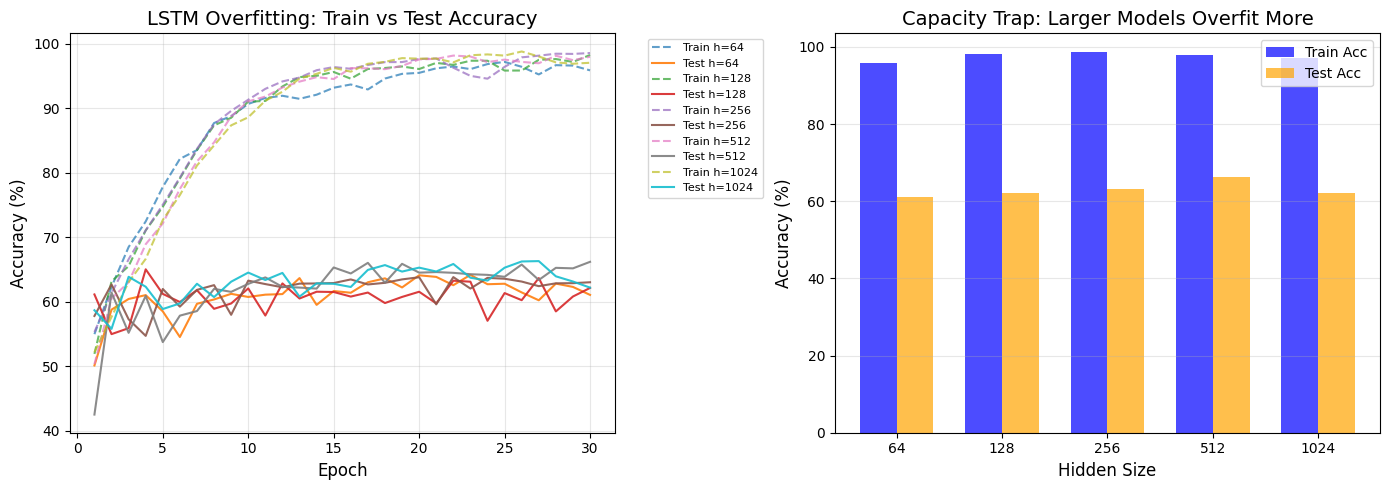


>>> KEY INSIGHT <<<
The growing gap between Train (blue) and Test (orange) bars shows that
larger LSTMs memorize the training data but fail to generalize.


In [ ]:
# ==============================================================================
# VISUALIZATION: LSTM Overfitting Curves
# ==============================================================================
import matplotlib.pyplot as plt

if 'overfitting_results' in dir() and overfitting_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Train vs Test accuracy for each hidden size
    ax1 = axes[0]
    for hs in HIDDEN_SIZES:
        r = overfitting_results[hs]
        epochs = range(1, NUM_EPOCHS + 1)
        ax1.plot(epochs, [a*100 for a in r['train_history']], '--', alpha=0.7, label=f'Train h={hs}')
        ax1.plot(epochs, [a*100 for a in r['test_history']], '-', alpha=0.9, label=f'Test h={hs}')

    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy (%)', fontsize=12)
    ax1.set_title('LSTM Overfitting: Train vs Test Accuracy', fontsize=14)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Final accuracy and overfitting gap
    ax2 = axes[1]
    x = np.arange(len(HIDDEN_SIZES))
    width = 0.35

    train_accs = [overfitting_results[hs]['final_train_acc']*100 for hs in HIDDEN_SIZES]
    test_accs = [overfitting_results[hs]['final_test_acc']*100 for hs in HIDDEN_SIZES]

    bars1 = ax2.bar(x - width/2, train_accs, width, label='Train Acc', color='blue', alpha=0.7)
    bars2 = ax2.bar(x + width/2, test_accs, width, label='Test Acc', color='orange', alpha=0.7)

    ax2.set_xlabel('Hidden Size', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title('Capacity Trap: Larger Models Overfit More', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels(HIDDEN_SIZES)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('lstm_overfitting.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n>>> KEY INSIGHT <<<")
    print("The growing gap between Train (blue) and Test (orange) bars shows that")
    print("larger LSTMs memorize the training data but fail to generalize.")
else:
    print("Run the overfitting experiment first")

## Conclusions

**1. LSTM against MLP and Transformer - the comparison is weaker than the numbers suggest.**
On Omnivore the LSTM's final-epoch F1 is 49.64% (step) and 47.50% (recordings) against the
MLP's 55.50% and 55.77%, so on final-epoch F1 it loses. But the Omnivore LSTM runs swing 7–10
F1 points between adjacent late epochs, and their best epochs reach 59.64% and 54.86% - either
side of the MLP. **On this evidence the three architectures cannot be separated on Omnivore.**
AUC is the more stable comparison and gives the LSTM 0.769 against the MLP's 0.816 on the step
split, so if anything the MLP is ahead. On SlowFast the LSTM is stable and clearly strongest
(51.05% step, 55.53% recordings).

**2. Backbones.** Omnivore gives far better ranking: AUC 0.769 against SlowFast's 0.683 on
the step split, 0.610 against 0.590 on recordings. SlowFast's higher F1 comes with accuracy
below 50% (47.62% and 48.44%) and recall of 87.55% and 89.63%, meaning the model predicts
positive almost everywhere and harvests recall - an F1 that a majority-positive predictor
would also obtain. Read AUC here, not F1. This is the same lesson the per-category analysis
reaches from the opposite direction: F1 at a fixed threshold reports the threshold as much as
the model.

**3. Splits.** Every model scores substantially higher AUC on the step split than on the
recordings split (LSTM/Omnivore 0.769 against 0.610). The recordings split holds out whole
recordings, so no step from a test recording is seen in training; the step split does not
guarantee that. The recordings split is the honest protocol and the one Substeps 2 and 4 use.

**4. The threshold does much of the work.** The same trained model is scored at 0.6 on the
step split and 0.5 on recordings. Where precision and recall are as unbalanced as the
Transformer's recordings run (38.12% precision, 92.53% recall), F1 mostly reports where the
threshold sits, not how good the model is.

### Carrying this into the extension

These baselines set the reference point for the pipeline built in Substeps 1–4: recording-level
verification from EgoVLP features, on the recordings split, reported with balanced accuracy and
AUC alongside F1 for exactly the reason section 4 gives.
